# 06 — ML SED Generation

This notebook demonstrates the ML generator, which produces complete SEDs from stellar parameters alone — no input spectrum required.

**Use case:** Generate SEDs at arbitrary (Teff, logg, [M/H]) points that are not present in any grid, for example to densify a sparse grid before feeding it to MESA.

**Key class:** `MLGenerator` (accessed via `SED.ml_generator()`)

**Difference from the completer:** The completer *extends* an existing spectrum's wavelength range. The generator *creates* a spectrum from scratch using only stellar parameters.

In [3]:
from sed_tools.api import SED
import matplotlib.pyplot as plt
import numpy as np

## 1. Initialising the Generator

In [4]:
generator = SED.ml_generator()
print("MLGenerator initialised")
print("  generator.train(grid=...)              — train on a catalog's flux cube")
print("  generator.load(name=...)               — load a saved model")
print("  generator.generate(teff, logg, meta)   — generate a single SED")
print("  generator.generate_with_outputs(...)   — generate + save diagnostic plots")
print("  generator.parameter_ranges()           — check valid input range")

MLGenerator initialised
  generator.train(grid=...)              — train on a catalog's flux cube
  generator.load(name=...)               — load a saved model
  generator.generate(teff, logg, meta)   — generate a single SED
  generator.generate_with_outputs(...)   — generate + save diagnostic plots
  generator.parameter_ranges()           — check valid input range


## 2. Training

The generator trains on a flux cube: it learns the mapping (Teff, logg, [M/H]) → full SED. Log-scaling handles the flux dynamic range.

In [5]:
generator.train(
    grid='Kurucz2003all',
    epochs=200,
    batch_size=64,
    save_name='sed_generator_kurucz',
)

Loading flux cube...
  Grid: 17 Teff × 5 logg × 5 [M/H] = 425 total SEDs
  Original wavelength: 147 - 1600000 Å
  Processing 425 SEDs...
  Prepared 269 valid samples
  Teff: 4000 - 6750 K
  logg: 3.00 - 5.00
  [M/H]: -1.00 - 0.50
  Average coverage: 94.4%
Normalizing data...
  Flux log10 range: [-25.00, 7.41]
  Input: (269, 3), Output: (269, 1000)
Building network: 3 → [512, 512, 256, 256] → 1000

Training for up to 200 epochs...
------------------------------------------------------------
  Epoch  10: train=0.112662, val=0.104738, lr=1.00e-03
  Epoch  20: train=0.028219, val=0.038058, lr=1.00e-03
  Epoch  30: train=0.019583, val=0.020988, lr=1.00e-03
  Epoch  40: train=0.018690, val=0.012793, lr=1.00e-03
  Epoch  50: train=0.016295, val=0.009990, lr=1.00e-03
  Epoch  60: train=0.012490, val=0.006962, lr=1.00e-03
  Epoch  70: train=0.016486, val=0.009576, lr=1.00e-03
  Epoch  80: train=0.012197, val=0.006224, lr=1.00e-03
  Epoch  90: train=0.010763, val=0.005598, lr=1.00e-03
  Epoch 10

## 3. Loading a Pre-trained Model

In [6]:
generator.load('sed_generator_kurucz')
print(f"Loaded model. Valid range: {generator.parameter_ranges()}")

Loaded generator from: /home/njm/SED_Tools/data/stellar_models/models/sed_generator_kurucz
Loaded model. Valid range: {'teff': (4000.0, 6750.0), 'logg': (3.0, 5.0), 'metallicity': (-1.0, 0.5)}


## 4. Generating a Single SED

`generator.generate()` returns `(wavelength, flux)` arrays directly.

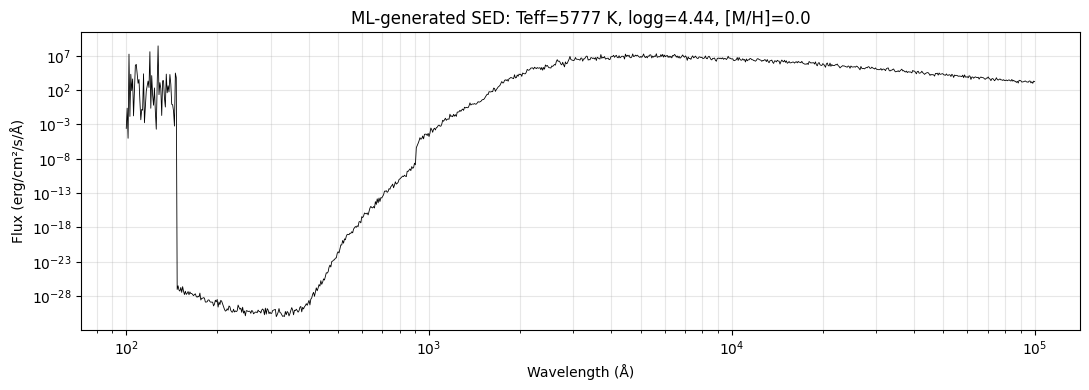

In [7]:
wl, fl = generator.generate(teff=5777, logg=4.44, metallicity=0.0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wl, fl, lw=0.6, color='k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (erg/cm²/s/Å)')
ax.set_title('ML-generated SED: Teff=5777 K, logg=4.44, [M/H]=0.0')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 5. Generating with Diagnostic Outputs

`generate_with_outputs()` saves comparison plots alongside the spectrum — useful for checking generation quality.

In [8]:
wl, fl = generator.generate_with_outputs(
    teff=5777,
    logg=4.44,
    metallicity=0.0,
    output_dir='output/sun_sed',
)
# # Saves e.g. output/sun_sed/sed_T5777_g4.44_m+0.00_spectrum.png

  Saved SED data: output/sun_sed/sed_T5777_g4.44_m+0.00.txt
  Saved SED plot: output/sun_sed/sed_T5777_g4.44_m+0.00_spectrum.png
  Saved parameter space plot: output/sun_sed/sed_T5777_g4.44_m+0.00_params.png


## 6. Comparing Generated vs Grid Spectra

 useful quality check: compare the generated SED against the nearest real grid point.

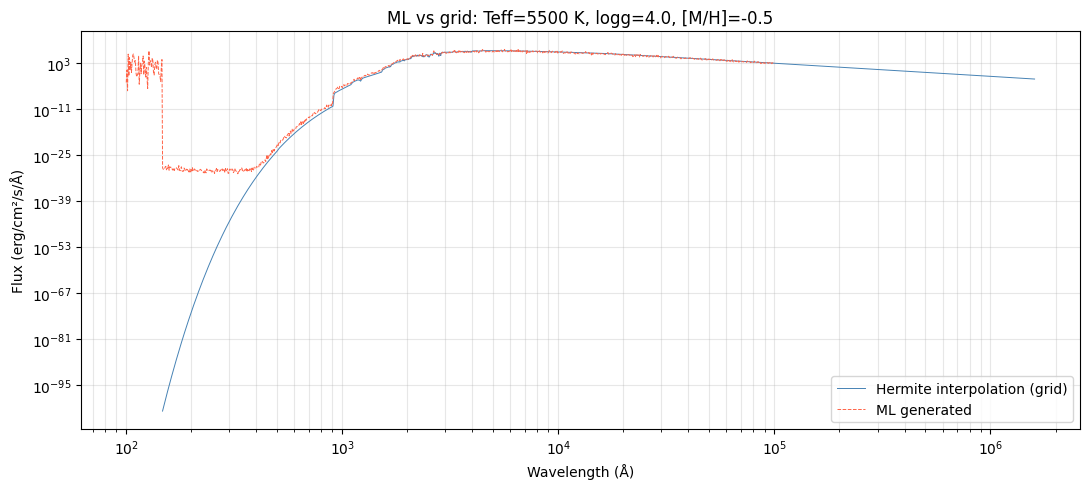

In [9]:
teff_test, logg_test, meta_test = 5500, 4.0, -0.5
wl_ml, fl_ml = generator.generate(teff=teff_test, logg=logg_test, metallicity=meta_test)

grid = SED.local('Kurucz2003all')
spec_grid = grid(teff=teff_test, logg=logg_test, metallicity=meta_test)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(spec_grid.wl, spec_grid.fl, lw=0.7, label='Hermite interpolation (grid)', color='steelblue')
ax.plot(wl_ml,        fl_ml,         lw=0.7, label='ML generated',                color='tomato',
        linestyle='--')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (erg/cm²/s/Å)')
ax.set_title(f'ML vs grid: Teff={teff_test} K, logg={logg_test}, [M/H]={meta_test}')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()